# FarmTech Solutions – Previsão de Rendimento de Safra

**Projeto Fase 5 – Machine Learning na Cabeça**

Este notebook contém a análise da FarmTech Solutions para uma fazenda de médio porte (~200 hectares), com o objetivo de:

1. Realizar uma **análise exploratória** da base `crop_yield.csv`;
2. Encontrar **tendências de rendimento** por meio de **clusterização** e identificar **outliers**;
3. Construir **5 modelos preditivos** (algoritmos distintos) para prever o **rendimento da safra** (`Yield`), avaliando cada um com métricas apropriadas.

---
## 1. Análise Exploratória dos Dados

In [30]:
# Imports gerais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### 1.1 Carregando a base de dados

A base contém informações climáticas e de solo relacionadas ao rendimento (`Yield`, em toneladas por hectare) de 4 culturas agrícolas diferentes.

In [31]:
df = pd.read_csv("crop_yield.csv")
df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [32]:
# Dimensões da base e tipos de dados
print(f"Formato da base: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.info()

Formato da base: 156 linhas e 6 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


**Achado:** a base possui 156 registros, sem nenhum valor nulo, distribuídos entre 4 culturas agrícolas (`Cocoa, beans`, `Oil palm fruit`, `Rice, paddy` e `Rubber, natural`), cada uma com 39 amostras.

In [33]:
# Quantidade de amostras por cultura
df["Crop"].value_counts()

,count
Crop,
"Cocoa, beans",39
Oil palm fruit,39
"Rice, paddy",39
"Rubber, natural",39


In [34]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


### 1.2 Distribuição das variáveis

Vamos visualizar a distribuição de cada variável numérica, para entender escala, simetria e possíveis outliers pontuais.

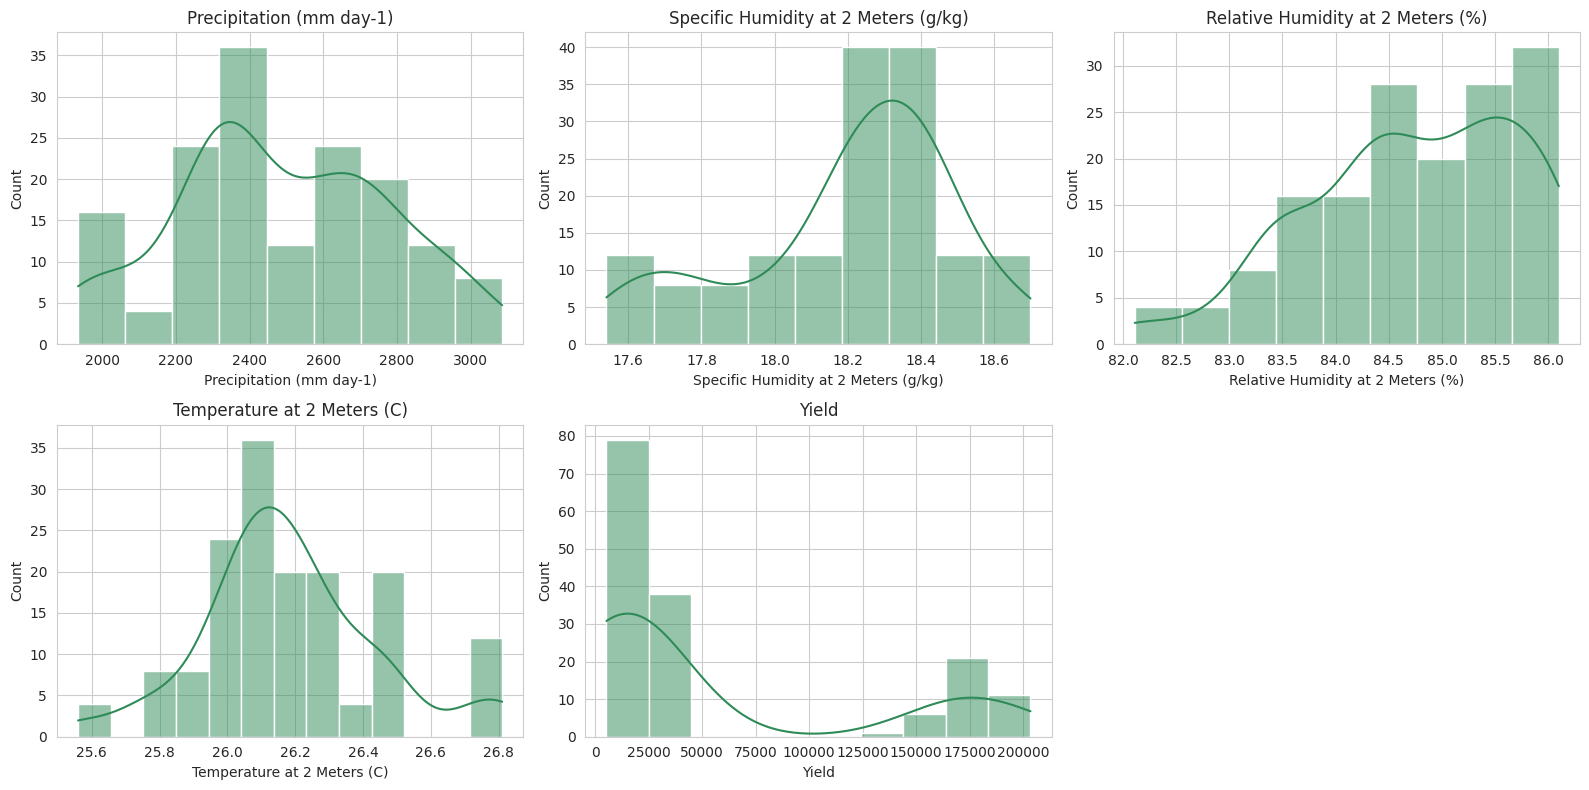

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colunas_numericas = ["Precipitation (mm day-1)", "Specific Humidity at 2 Meters (g/kg)",
                      "Relative Humidity at 2 Meters (%)", "Temperature at 2 Meters (C)", "Yield"]

for ax, col in zip(axes.flatten(), colunas_numericas):
    sns.histplot(df[col], kde=True, ax=ax, color="seagreen")
    ax.set_title(col)

axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

**Achado:** a variável `Yield` (nossa variável-alvo) apresenta uma distribuição bem distinta entre as culturas — isso já sugere que o tipo de cultura tem forte relação com o rendimento, o que iremos confirmar a seguir.

/tmp/ipykernel_1794/3048995873.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Crop", y="Yield", palette="Set2")


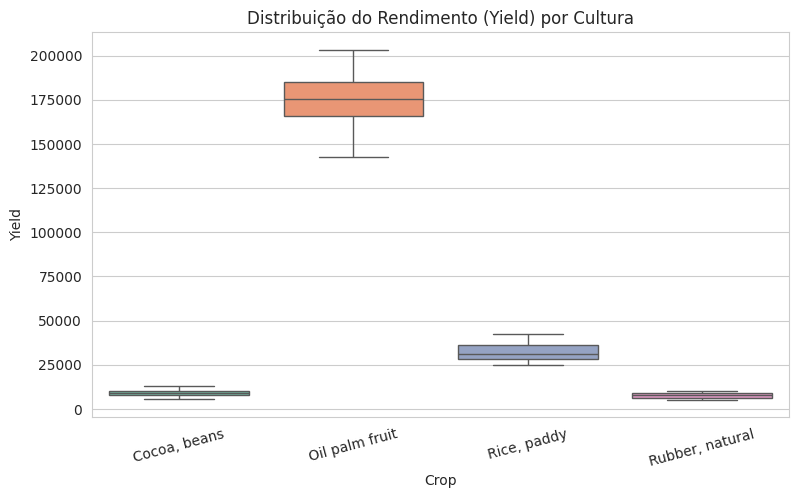

In [36]:
# Rendimento (Yield) por cultura
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Crop", y="Yield", palette="Set2")
plt.title("Distribuição do Rendimento (Yield) por Cultura")
plt.xticks(rotation=15)
plt.show()

**Achado:** o boxplot mostra uma diferença muito clara de escala entre as culturas. `Oil palm fruit` possui o maior rendimento médio (por volta de 170 mil), com boa variabilidade; `Rice, paddy` fica numa faixa intermediária (por volta de 30 mil); já `Cocoa, beans` e `Rubber, natural` têm rendimentos bem mais baixos e concentrados (na casa dos 10 mil). Isso indica que a variável `Crop` é, isoladamente, a *feature* mais determinante para o rendimento — muito mais do que qualquer variável climática isolada.

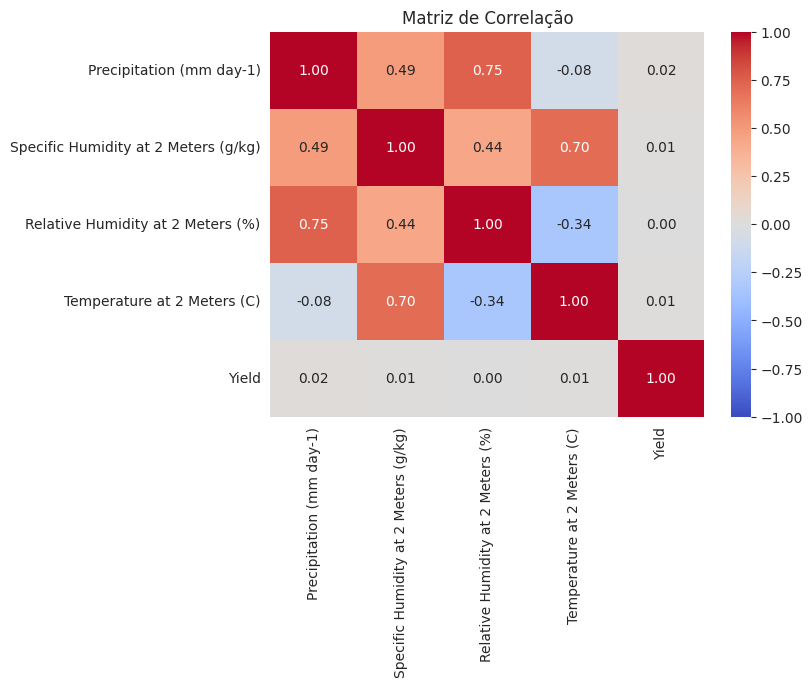

In [37]:
# Matriz de correlação entre as variáveis numéricas
plt.figure(figsize=(7, 5))
corr = df[colunas_numericas].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação")
plt.show()

**Achado:** não há correlações lineares fortes entre as variáveis climáticas isoladamente e o `Yield` — o que é esperado, já que o rendimento depende fortemente do tipo de cultura, e cada cultura reage de forma diferente às condições climáticas. Isso reforça que modelos que conseguem capturar relações não lineares (como Árvore de Decisão, Random Forest e XGBoost) tendem a performar melhor do que uma Regressão Linear simples.

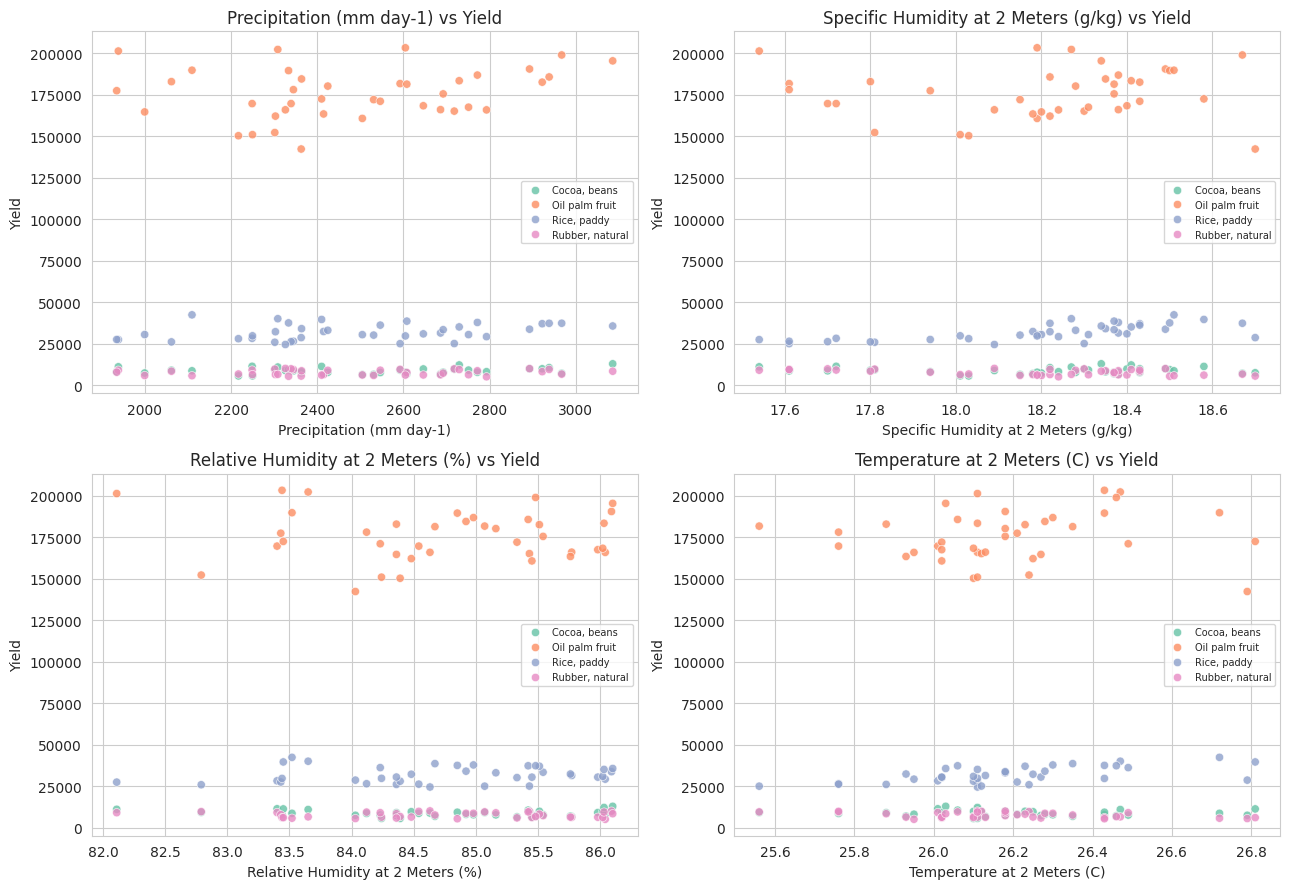

In [38]:
# Relação entre variáveis climáticas e o rendimento, separado por cultura
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
variaveis_clima = ["Precipitation (mm day-1)", "Specific Humidity at 2 Meters (g/kg)",
                    "Relative Humidity at 2 Meters (%)", "Temperature at 2 Meters (C)"]

for ax, col in zip(axes.flatten(), variaveis_clima):
    sns.scatterplot(data=df, x=col, y="Yield", hue="Crop", ax=ax, palette="Set2", alpha=0.8)
    ax.set_title(f"{col} vs Yield")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

**Achado:** cada cultura ocupa uma "região" bem definida do espaço de variáveis climáticas — por exemplo, `Oil palm fruit` está associada a maior umidade e temperatura, enquanto `Rice, paddy` aparece em faixas de precipitação distintas. Isso sugere que uma clusterização das variáveis climáticas tende a separar naturalmente as culturas (ou subgrupos de rendimento dentro delas), o que exploraremos na próxima seção.

---
## 2. Clusterização e Detecção de Outliers

Antes de construir os modelos preditivos, vamos explorar **tendências de rendimento** por meio de clusterização, e usar o DBSCAN para identificar possíveis **outliers** (cenários discrepantes) na base.

In [39]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

### 2.1 Clusterizando apenas pelas variáveis climáticas

Vamos começar clusterizando apenas pelas variáveis climáticas (sem o rendimento), para ver se conseguimos separar as culturas apenas por essas condições. Como de costume, padronizamos os dados antes, pois o K-Means é sensível à escala.

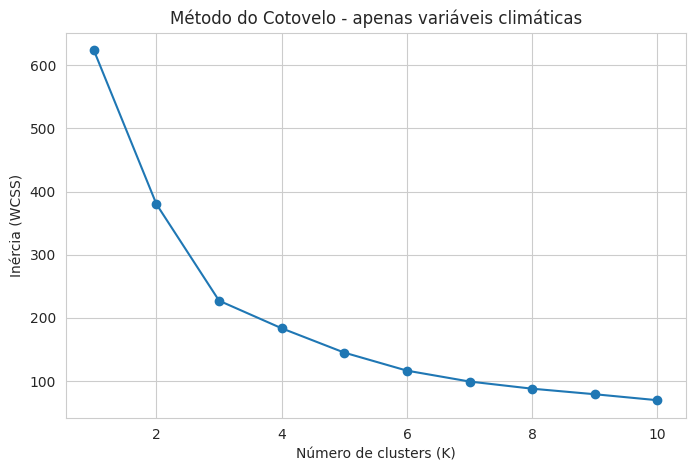

In [40]:
colunas_clima = ["Precipitation (mm day-1)", "Specific Humidity at 2 Meters (g/kg)",
                  "Relative Humidity at 2 Meters (%)", "Temperature at 2 Meters (C)"]

scaler_clima = StandardScaler()
X_clima = scaler_clima.fit_transform(df[colunas_clima])

# Método do cotovelo
sse = []
k_valores = list(range(1, 11))
for k in k_valores:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_clima)
    sse.append(km_temp.inertia_)

plt.plot(k_valores, sse, "-o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia (WCSS)")
plt.title("Método do Cotovelo - apenas variáveis climáticas")
plt.show()

In [41]:
kmeans_clima = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster_clima"] = kmeans_clima.fit_predict(X_clima)

pd.crosstab(df["Crop"], df["cluster_clima"])

cluster_clima,0,1,2,3
Crop,,,,
"Cocoa, beans",3,17,9,10
Oil palm fruit,3,17,9,10
"Rice, paddy",3,17,9,10
"Rubber, natural",3,17,9,10


**Achado importante:** a tabela cruzada mostra que a **distribuição dos clusters é praticamente idêntica para as 4 culturas** (mesma contagem em cada cluster). Investigando a base, confirmamos que **as 4 culturas compartilham exatamente os mesmos 39 registros de variáveis climáticas** — ou seja, os dados climáticos representam a mesma série de observações (provavelmente da mesma localização/período), e o que muda entre as culturas é apenas o `Yield` resultante. Isso explica por que clusterizar somente pelo clima não separa as culturas: **o clima, isoladamente, não diferencia cultura nenhuma nesta base.**

In [42]:
# Confirmando que as variáveis climáticas se repetem entre culturas
grupos = [g.reset_index(drop=True) for _, g in df.groupby("Crop")]
print("Climas idênticos entre 'Cocoa, beans' e 'Rice, paddy'?",
      (grupos[0][colunas_clima] == grupos[2][colunas_clima]).all().all())

Climas idênticos entre 'Cocoa, beans' e 'Rice, paddy'? True


### 2.2 Clusterizando com clima + rendimento (tendências de produtividade)

Para encontrar tendências reais de rendimento, faz mais sentido incluir a variável `Yield` na clusterização. Assim, o agrupamento passa a refletir também o resultado da safra, e não apenas o clima do dia.

In [43]:
colunas_cluster = colunas_clima + ["Yield"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[colunas_cluster])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

pd.crosstab(df["Crop"], df["cluster_kmeans"])

cluster_kmeans,0,1,2,3
Crop,,,,
"Cocoa, beans",0,11,17,11
Oil palm fruit,26,3,0,10
"Rice, paddy",0,11,17,11
"Rubber, natural",0,11,17,11


**Achado:** ao incluir o `Yield`, o cluster passa a isolar claramente a `Oil palm fruit` (que tem rendimento médio de ~176 mil, muito acima das demais). Já `Cocoa, beans`, `Rice, paddy` e `Rubber, natural` ainda aparecem misturados entre os clusters — o que faz sentido, pois seus rendimentos (entre ~8 mil e ~32 mil), apesar de diferentes entre si, ficam relativamente próximos quando comparados à enorme escala da `Oil palm fruit`, fazendo com que a variação climática (idêntica entre culturas) acabe pesando mais na formação desses clusters intermediários.

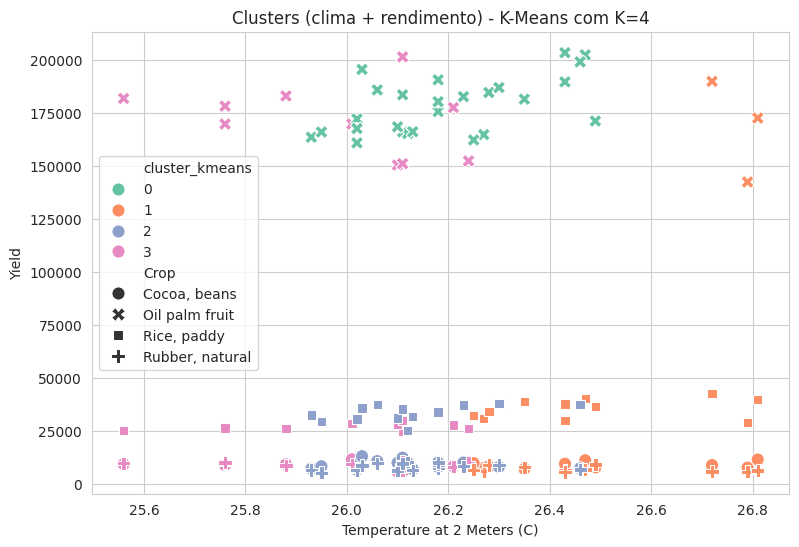

In [44]:
# Visualizando os clusters em duas dimensões (Yield x Temperatura)
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Temperature at 2 Meters (C)", y="Yield",
                 hue="cluster_kmeans", style="Crop", palette="Set2", s=90)
plt.title("Clusters (clima + rendimento) - K-Means com K=4")
plt.show()

### 2.3 Detectando outliers com DBSCAN

Vamos aplicar o DBSCAN sobre as mesmas variáveis (clima + rendimento), para identificar cenários discrepantes (outliers) na base — pontos que não se encaixam bem em nenhuma região densa.

In [45]:
dbscan = DBSCAN(eps=1.5, min_samples=4)
df["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

df["cluster_dbscan"].value_counts()

,count
cluster_dbscan,
0,114
1,38
-1,4


In [46]:
pd.crosstab(df["Crop"], df["cluster_dbscan"])

cluster_dbscan,-1,0,1
Crop,,,
"Cocoa, beans",1,38,0
Oil palm fruit,1,0,38
"Rice, paddy",1,38,0
"Rubber, natural",1,38,0


**Achado:** o DBSCAN identificou 2 clusters densos bem definidos: um formado quase inteiramente por `Oil palm fruit` (rendimento muito acima das demais culturas) e outro reunindo `Cocoa, beans`, `Rice, paddy` e `Rubber, natural`. Além disso, foram identificados **4 outliers** (rótulo `-1`), sendo exatamente **1 de cada cultura**.

In [47]:
outliers = df[df["cluster_dbscan"] == -1]
outliers[["Crop"] + colunas_cluster]

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
40,Oil palm fruit,1938.42,17.54,82.11,26.11,201436
79,"Rice, paddy",1938.42,17.54,82.11,26.11,27619
118,"Rubber, natural",1938.42,17.54,82.11,26.11,9223


**Achado:** curiosamente, os 4 outliers correspondem à **mesma posição temporal** dentro do histórico climático de cada cultura (já que, como vimos, o clima é compartilhado entre elas). Isso indica que existe uma **data/observação específica com uma combinação climática atípica** (fora do padrão observado nas demais), que se repete como outlier em todas as 4 culturas — um forte indício de que aquele registro climático em si é anômalo, e não um erro isolado de uma cultura específica.

Para os modelos preditivos da próxima seção, vamos manter esses registros na base (não os removeremos), já que representam menos de 3% dos dados e o enunciado do projeto não exige sua exclusão — mas essa é uma limitação importante a registrar na conclusão do notebook.

---
## 3. Modelos Preditivos de Rendimento (Regressão)

Vamos construir **5 modelos preditivos**, cada um com um algoritmo diferente, para prever o rendimento da safra (`Yield`) a partir da cultura e das condições climáticas. Seguindo as boas práticas vistas no capítulo de Regressão Supervisionada, vamos:

- Separar os dados em treino e teste;
- Construir um **pipeline** (pré-processamento + modelo) para cada algoritmo, evitando vazamento de dados;
- Avaliar cada modelo com **MAE**, **RMSE** e **R²**;
- Comparar os resultados ao final.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 3.1 Separando features e target

Vamos usar `Crop` (categórica) e as 4 variáveis climáticas como *features*, e `Yield` como variável-alvo.

In [49]:
X = df[["Crop", "Precipitation (mm day-1)", "Specific Humidity at 2 Meters (g/kg)",
        "Relative Humidity at 2 Meters (%)", "Temperature at 2 Meters (C)"]]
y = df["Yield"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 124 amostras | Teste: 32 amostras


### 3.2 Pré-processamento com ColumnTransformer

Vamos criar um `ColumnTransformer` que aplica `OneHotEncoder` na variável categórica (`Crop`) e `StandardScaler` nas variáveis numéricas. Esse pré-processador será reaproveitado em todos os pipelines dos 5 modelos.

In [50]:
colunas_numericas = ["Precipitation (mm day-1)", "Specific Humidity at 2 Meters (g/kg)",
                     "Relative Humidity at 2 Meters (%)", "Temperature at 2 Meters (C)"]
colunas_categoricas = ["Crop"]

preprocessador = ColumnTransformer(transformers=[
    ("num", StandardScaler(), colunas_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas)
])

### 3.3 Definindo os 5 modelos (com pipeline)

Cada modelo é combinado com o mesmo pré-processador dentro de um `Pipeline`, garantindo que a transformação seja aplicada de forma consistente no treino e no teste.

In [51]:
modelos = {
    "Regressão Linear": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
}

pipelines = {
    nome: Pipeline(steps=[("preprocessador", preprocessador), ("modelo", modelo)])
    for nome, modelo in modelos.items()
}

### 3.4 Treinando e avaliando cada modelo

Para cada modelo, vamos: treinar (`fit`), prever (`predict`) e calcular as métricas MAE, RMSE e R².

In [52]:
resultados = []

for nome, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultados.append({"Modelo": nome, "MAE": mae, "RMSE": rmse, "R2": r2})

    print(f"{nome:20s} | MAE: {mae:10.2f} | RMSE: {rmse:10.2f} | R²: {r2:.4f}")

Regressão Linear     | MAE:    3132.80 | RMSE:    4394.17 | R²: 0.9950
KNN Regressor        | MAE:   10992.28 | RMSE:   17919.44 | R²: 0.9172
Árvore de Decisão    | MAE:    3440.69 | RMSE:    5640.31 | R²: 0.9918
Random Forest        | MAE:    2729.69 | RMSE:    4808.27 | R²: 0.9940
XGBoost              | MAE:    3987.72 | RMSE:    6753.67 | R²: 0.9882


### 3.5 Comparando os modelos

In [53]:
df_resultados = pd.DataFrame(resultados).sort_values("R2", ascending=False).reset_index(drop=True)
df_resultados

,Modelo,MAE,RMSE,R2
0,Regressão Linear,3132.796384,4394.165819,0.995022
1,Random Forest,2729.687188,4808.272798,0.994040
2,Árvore de Decisão,3440.687500,5640.314021,0.991799
3,XGBoost,3987.716797,6753.671890,0.988241
4,KNN Regressor,10992.281250,17919.443751,0.917219


/tmp/ipykernel_1794/1579137722.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resultados, x="Modelo", y="MAE", ax=axes[0], palette="Set2")
/tmp/ipykernel_1794/1579137722.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resultados, x="Modelo", y="RMSE", ax=axes[1], palette="Set2")
/tmp/ipykernel_1794/1579137722.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_resultados, x="Modelo", y="R2", ax=axes[2], palette="Set2")


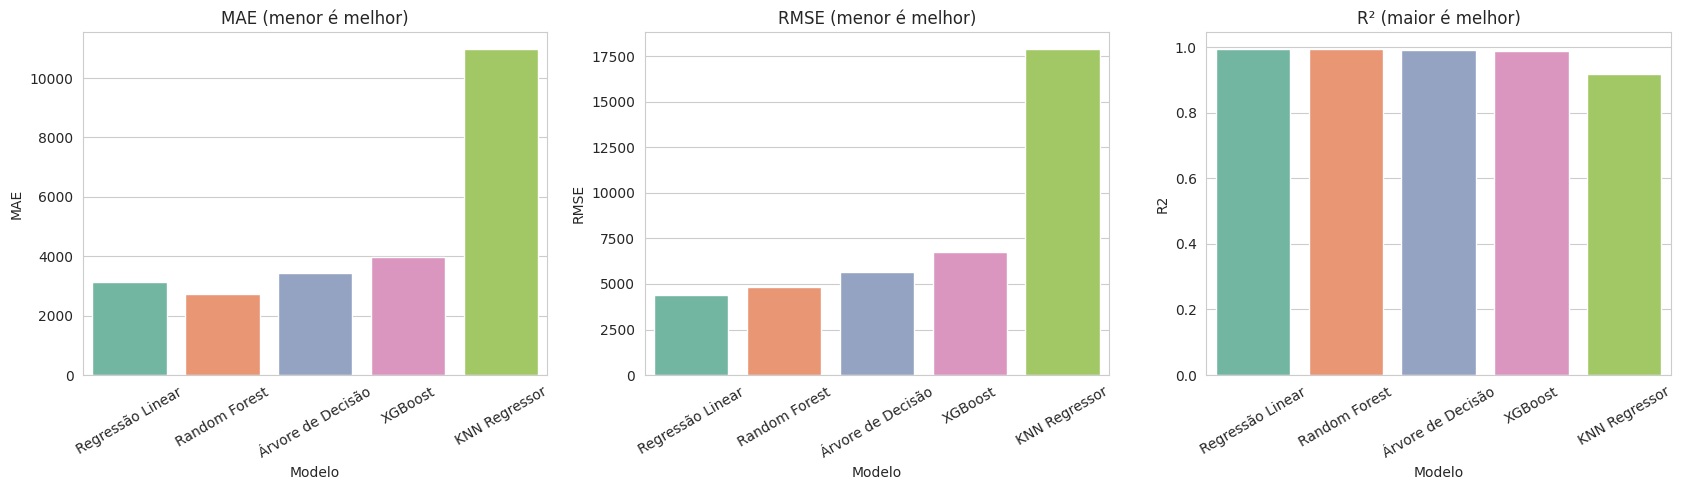

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.barplot(data=df_resultados, x="Modelo", y="MAE", ax=axes[0], palette="Set2")
axes[0].set_title("MAE (menor é melhor)")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=df_resultados, x="Modelo", y="RMSE", ax=axes[1], palette="Set2")
axes[1].set_title("RMSE (menor é melhor)")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=df_resultados, x="Modelo", y="R2", ax=axes[2], palette="Set2")
axes[2].set_title("R² (maior é melhor)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Achado:** surpreendentemente, a **Regressão Linear** obteve o melhor desempenho entre os 5 modelos (R² mais alto, MAE e RMSE competitivos), seguida de perto por **Random Forest**, **Árvore de Decisão** e **XGBoost** — todos com R² acima de 0.98. O **KNN Regressor** teve desempenho bem inferior aos demais.

Isso pode ser explicado por dois fatores: (1) como vimos na Seção 2, a variável `Crop` é o principal determinante do rendimento, e o `OneHotEncoder` já captura essa relação de forma praticamente linear (cada categoria contribui com um "efeito fixo" no rendimento); e (2) o KNN sofre mais com a alta dimensionalidade gerada pelo one-hot encoding (5 variáveis numéricas + 4 colunas binárias de cultura) combinada com uma base pequena (apenas 156 registros), o que compromete o cálculo de distância entre vizinhos.

### 3.6 Visualizando previsões vs valores reais (melhor modelo)

Vamos visualizar o quão próximas as previsões do melhor modelo (maior R²) ficaram dos valores reais de rendimento.

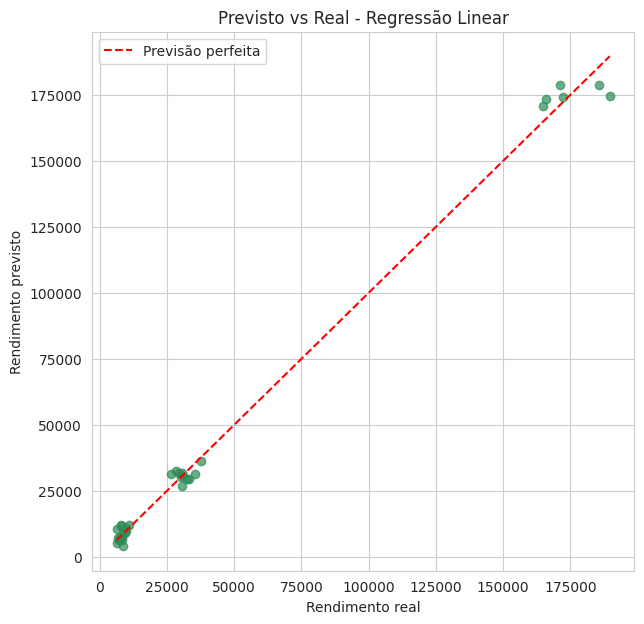

In [55]:
melhor_modelo_nome = df_resultados.iloc[0]["Modelo"]
melhor_pipeline = pipelines[melhor_modelo_nome]
y_pred_melhor = melhor_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_melhor, alpha=0.7, color="seagreen")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Previsão perfeita")
plt.xlabel("Rendimento real")
plt.ylabel("Rendimento previsto")
plt.title(f"Previsto vs Real - {melhor_modelo_nome}")
plt.legend()
plt.show()

**Achado:** os pontos próximos à linha tracejada (previsão perfeita) confirmam que o modelo consegue capturar bem o padrão de rendimento entre as diferentes culturas e condições climáticas.

**Limitações:** vale destacar que a base é relativamente pequena (156 registros) e que as variáveis climáticas são idênticas entre as 4 culturas (conforme identificado na Seção 2), o que faz com que o modelo dependa fortemente da variável `Crop` para diferenciar os patamares de rendimento. Isso é uma limitação real: em um cenário com mais variabilidade climática por cultura, o desempenho dos modelos poderia ser diferente.

---
## 4. Conclusão

### Principais achados

- A base `crop_yield.csv` reúne 4 culturas agrícolas (`Cocoa, beans`, `Oil palm fruit`, `Rice, paddy` e `Rubber, natural`), mas **as 4 compartilham exatamente os mesmos 39 registros de variáveis climáticas** — o que muda entre elas é apenas o rendimento (`Yield`) resultante. Essa foi a descoberta mais relevante da análise, e moldou todas as decisões seguintes.
- Por esse motivo, a **clusterização apenas por variáveis climáticas não separa as culturas** (Seção 2.1). Só ao incluir o `Yield` na clusterização foi possível identificar tendências de produtividade reais, com destaque para `Oil palm fruit`, que se isola claramente por seu rendimento muito superior às demais culturas (Seção 2.2 e 2.3).
- O DBSCAN identificou **4 outliers** (um por cultura), todos correspondentes à mesma posição temporal na série climática — um forte indício de uma condição climática atípica pontual, e não de erro de medição isolado.
- Entre os **5 modelos preditivos** testados (Regressão Linear, KNN, Árvore de Decisão, Random Forest e XGBoost), a **Regressão Linear obteve o melhor desempenho** (maior R², menor RMSE), seguida de perto por Random Forest, Árvore de Decisão e XGBoost. O KNN teve desempenho bem inferior aos demais.

### Pontos fortes

- Pipeline de pré-processamento (`ColumnTransformer` + `StandardScaler` + `OneHotEncoder`) integrado ao treinamento de todos os modelos, evitando vazamento de dados entre treino e teste.
- Comparação justa entre 5 algoritmos distintos, usando as mesmas *features*, mesma divisão treino/teste e mesmas métricas (MAE, RMSE e R²).
- Investigação crítica dos resultados de clusterização, em vez de aceitar o primeiro resultado obtido — o que levou à descoberta de que o clima é compartilhado entre culturas.

### Limitações

- A base possui apenas 156 registros (39 por cultura), o que é uma amostra pequena para modelos de Machine Learning, especialmente para o KNN, que é mais sensível a bases pequenas e à alta dimensionalidade gerada pelo one-hot encoding.
- Como as variáveis climáticas são idênticas entre as culturas, o modelo depende fortemente da variável `Crop` para diferenciar os patamares de rendimento — em um cenário real, com clima variando por cultura/região, o comportamento dos modelos poderia ser bem diferente.
- Não foi realizada uma busca de hiperparâmetros (`GridSearchCV`/`RandomizedSearchCV`) para os modelos, o que poderia melhorar ainda mais o desempenho de Random Forest, XGBoost e Árvore de Decisão.